In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [74]:
# Load the dataset

path_1 ="data/financial_impact.csv"
path_2 ="data/incidents_master.csv"
path_3 ="data/market_impact.csv"
data_finan = pd.read_csv(path_1)
data_incident = pd.read_csv(path_2)
data_market = pd.read_csv(path_3)

In [75]:
df = pd.merge(data_finan, data_incident, on='incident_id')
df_final = pd.merge(df, data_market, on='incident_id', how = "left")
df_final

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,...,1.0000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,4682151.47,disclosed,NaN,NaN,NaN,3642946.48,1029035.85,NaN,1772460.33,...,0.9824,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,2684607.92,estimated,NaN,NaN,NaN,2574871.33,206822.23,NaN,NaN,...,1.0000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
773,2022-0508-002,3033672.85,disclosed,NaN,NaN,NaN,2902284.99,674141.76,NaN,3361596.17,...,1.0000,False,6.120250e+09,3.0012,0.010470,0.020021,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
774,2023-0310-002,24538239.51,estimated,75000000.00,51884175.62,FBI disclosure,18670182.02,5183553.28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
775,2025-1112-001,740926.80,estimated,NaN,NaN,NaN,243853.82,44814.27,NaN,601306.07,...,1.0000,False,3.327991e+09,2.5376,0.030708,0.044332,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
776,2023-0620-002,14747328.10,calculated,57715082.14,NaN,NaN,7841839.87,3975025.14,NaN,NaN,...,0.3723,False,3.203381e+10,2.0501,0.037334,0.046740,180.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [76]:
print("Finance Data", data_finan.shape)
print("Incident Data", data_incident.shape)
print("Market Data", data_market.shape)

print("Merge Data", df_final.shape)

Finance Data (778, 19)
Incident Data (850, 32)
Market Data (358, 31)
Merge Data (778, 80)


In [77]:
# list of columns to drop based on correlation analysis
cols_to_drop = [
    # redundant loss-related features
    "direct_loss_usd",
    "recovery_cost_usd",
    "legal_fees_usd",
    "total_loss_lower_bound",
    "total_loss_upper_bound",
    "inflation_adjusted_usd",

    # volatility duplication
    "post_incident_volatility_30d",

    # redundant price columns
    "price_7d_before",
    "price_disclosure_day",   # keep this if you prefer, otherwise remove others
    "price_1d_after",
    "price_7d_after",
    "price_30d_after",

    # duplicate abnormal return metrics
    "abnormal_return_1d",
    "abnormal_return_7d",
    "abnormal_return_30d",

    # statistical noise (not useful for ML models)
    "p_value_1d",
    "p_value_30d",
    "t_statistic_1d",
    "t_statistic_30d"
]

# drop columns safely (ignore errors if any column is missing)
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

# check result
print("Remaining columns:", df_final.columns.tolist())
print("Shape after cleanup:", df_final.shape)

Remaining columns: ['incident_id', 'direct_loss_method', 'ransom_demanded_usd', 'ransom_paid_usd', 'ransom_source', 'regulatory_fine_usd', 'insurance_payout_usd', 'total_loss_usd', 'total_loss_method', 'cpi_index_used', 'notes_x', 'created_at_x', 'updated_at_x', 'company_name', 'company_revenue_usd', 'country_hq', 'industry_primary', 'industry_secondary', 'employee_count', 'is_public_company', 'stock_ticker_x', 'incident_date', 'incident_date_estimated', 'discovery_date', 'disclosure_date', 'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 'attributed_group', 'attribution_confidence', 'data_compromised_records', 'data_type', 'systems_affected', 'downtime_hours', 'data_source_primary', 'data_source_secondary', 'data_source_type', 'confidence_tier', 'quality_score', 'quality_grade', 'review_flag', 'notes_y', 'created_at_y', 'updated_at_y', 'stock_ticker_y', 'volume_avg_30d_baseline', 'volume_disclosure_day', 'sector_index', 'sector_return_same_period', 'car_neg1_to_pos1

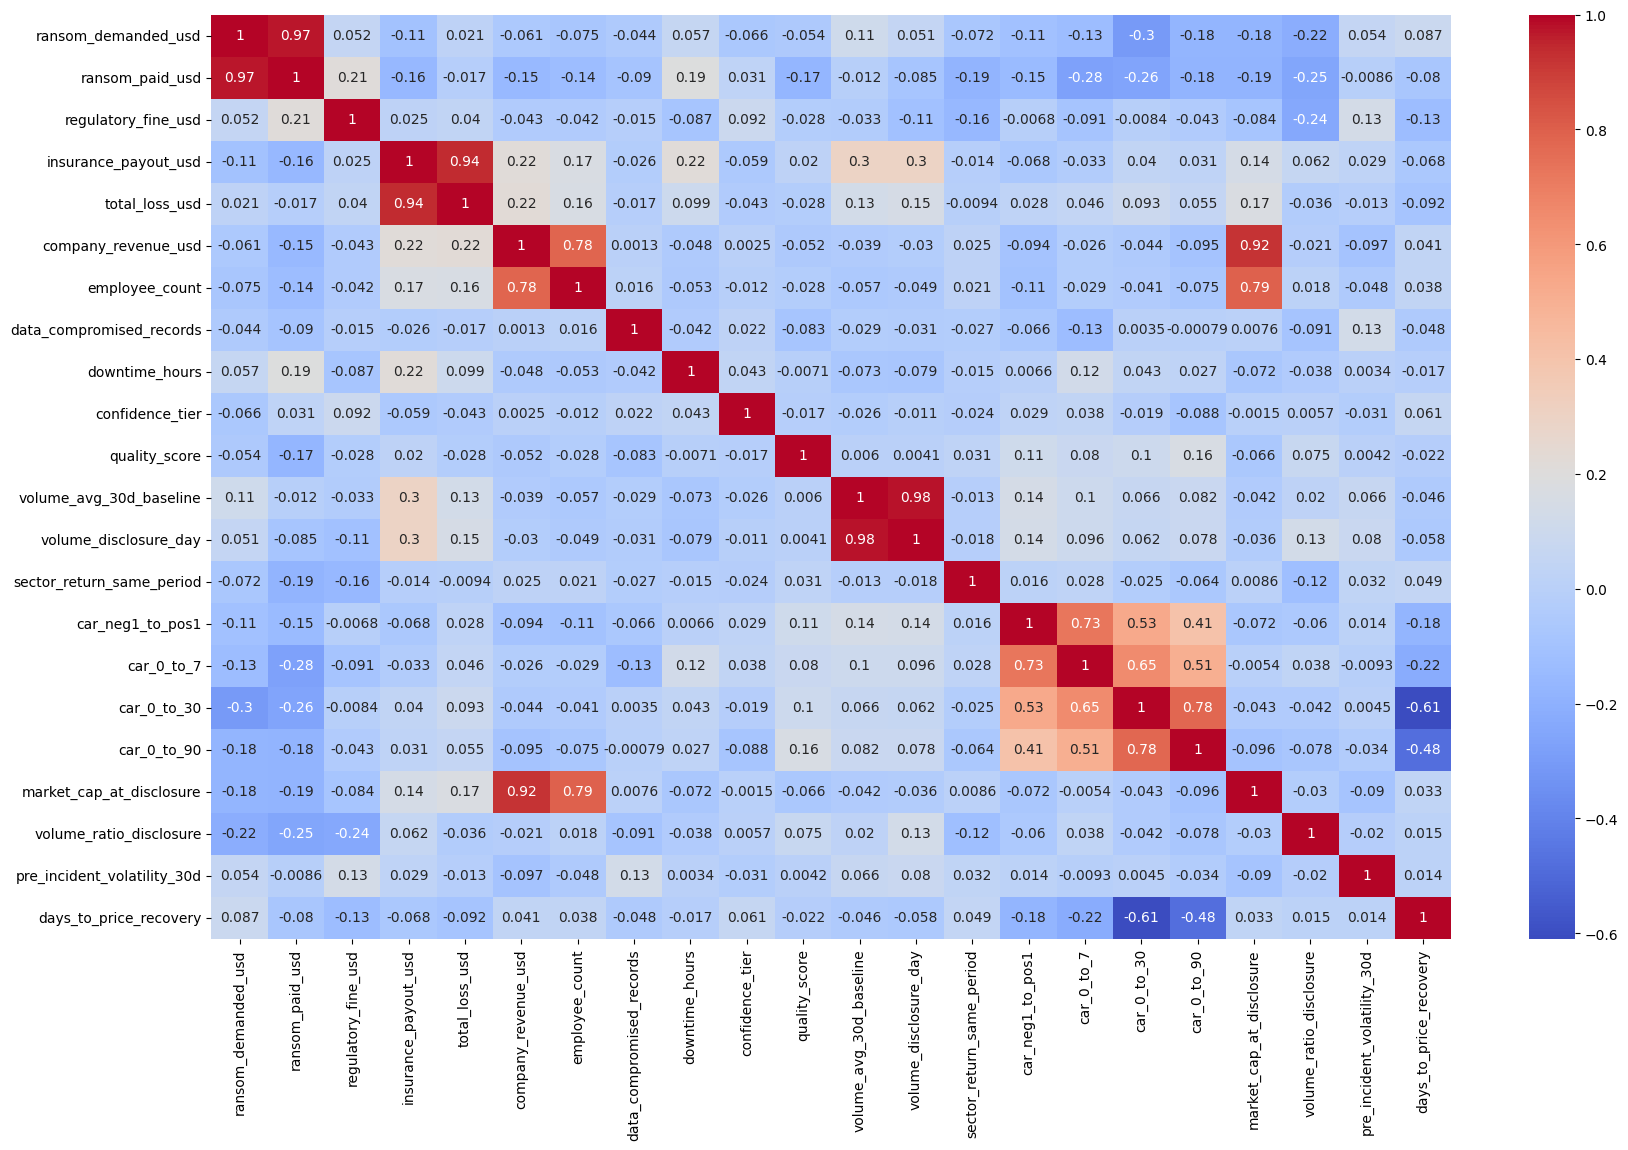

In [78]:
plt.figure(figsize=(20, 12))


import seaborn as sns
num_columns = df_final.select_dtypes(include=['number']).columns
cat_columns = df_final.select_dtypes(include=['object']).columns
df_final[num_columns] = df_final[num_columns]
corr_matrix = df_final[num_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.show()

In [79]:
corr_matrix.sort_values(by = "days_to_price_recovery", ascending = False)

,ransom_demanded_usd,ransom_paid_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,company_revenue_usd,employee_count,data_compromised_records,downtime_hours,confidence_tier,...,volume_disclosure_day,sector_return_same_period,car_neg1_to_pos1,car_0_to_7,car_0_to_30,car_0_to_90,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,days_to_price_recovery
days_to_price_recovery,0.087475,-0.080093,-0.132282,-0.067531,-0.092385,0.040642,0.038270,-0.047903,-0.017354,0.061282,...,-0.058300,0.048510,-0.177225,-0.221265,-0.609359,-0.479707,0.033377,0.014599,0.014378,1.000000
ransom_demanded_usd,1.000000,0.973830,0.051579,-0.105884,0.021372,-0.061248,-0.075097,-0.044054,0.057171,-0.065667,...,0.050733,-0.072315,-0.107588,-0.134017,-0.304594,-0.180293,-0.178827,-0.215271,0.053768,0.087475
confidence_tier,-0.065667,0.031475,0.091876,-0.058630,-0.042654,0.002514,-0.011525,0.022001,0.043263,1.000000,...,-0.010655,-0.024214,0.028976,0.038287,-0.019158,-0.087572,-0.001544,0.005728,-0.030762,0.061282
sector_return_same_period,-0.072315,-0.187149,-0.160185,-0.014274,-0.009380,0.024654,0.021441,-0.027141,-0.015104,-0.024214,...,-0.018207,1.000000,0.015526,0.028040,-0.025176,-0.063660,0.008649,-0.122608,0.031910,0.048510
company_revenue_usd,-0.061248,-0.153921,-0.042877,0.218534,0.220818,1.000000,0.780167,0.001313,-0.048336,0.002514,...,-0.030116,0.024654,-0.093876,-0.026161,-0.044426,-0.095033,0.919401,-0.020626,-0.096564,0.040642
employee_count,-0.075097,-0.135935,-0.042401,0.169273,0.162613,0.780167,1.000000,0.015661,-0.053339,-0.011525,...,-0.049331,0.021441,-0.105392,-0.029113,-0.040585,-0.074718,0.793216,0.017923,-0.048405,0.038270
market_cap_at_disclosure,-0.178827,-0.185996,-0.084414,0.141727,0.173857,0.919401,0.793216,0.007638,-0.071857,-0.001544,...,-0.036302,0.008649,-0.071583,-0.005412,-0.042653,-0.096352,1.000000,-0.029960,-0.090206,0.033377
volume_ratio_disclosure,-0.215271,-0.254807,-0.242496,0.061683,-0.035749,-0.020626,0.017923,-0.091057,-0.038351,0.005728,...,0.129913,-0.122608,-0.059571,0.037993,-0.042318,-0.077758,-0.029960,1.000000,-0.019529,0.014599
pre_incident_volatility_30d,0.053768,-0.008589,0.134781,0.029126,-0.012511,-0.096564,-0.048405,0.126622,0.003372,-0.030762,...,0.079978,0.031910,0.013780,-0.009286,0.004502,-0.034280,-0.090206,-0.019529,1.000000,0.014378
downtime_hours,0.057171,0.191484,-0.087040,0.218675,0.098966,-0.048336,-0.053339,-0.042134,1.000000,0.043263,...,-0.079449,-0.015104,0.006560,0.122842,0.042922,0.026967,-0.071857,-0.038351,0.003372,-0.017354


In [62]:
for col in cat_columns:
    print(col, df_final[col].nunique())

incident_id 778
direct_loss_method 3
ransom_source 6
total_loss_method 3
cpi_index_used 5
notes_x 143
created_at_x 1
updated_at_x 1
company_name 693
country_hq 38
industry_primary 20
industry_secondary 19
stock_ticker_x 334
incident_date 642
discovery_date 635
disclosure_date 645
attack_vector_primary 9
attack_vector_secondary 9
attack_chain 9
attributed_group 31
attribution_confidence 4
data_type 6
systems_affected 582
data_source_primary 778
data_source_secondary 352
data_source_type 5
quality_grade 3
review_flag 2
notes_y 60
created_at_y 1
updated_at_y 1
stock_ticker_y 296
sector_index 10
earnings_announcement_within_7d 2
notes 21
created_at 1
updated_at 1


In [81]:
df_final['incident_year'] = pd.to_datetime(df_final['incident_date']).dt.year
df_final['incident_month'] = pd.to_datetime(df_final['incident_date']).dt.month

df_final['disclosure_delay_days'] = (
    pd.to_datetime(df_final['disclosure_date']) - 
    pd.to_datetime(df_final['incident_date'])
).dt.days

df_final['discovery_delay_days'] = (
    pd.to_datetime(df_final['discovery_date']) - 
    pd.to_datetime(df_final['incident_date'])
).dt.days


cols_to_drop = [
    # IDs
    "incident_id",
    "company_name",
    "stock_ticker_x",

    # text
    "notes_x",
    "notes",
    "systems_affected",
    "data_source_type",
    "data_source_primary",
    "data_source_secondary",
    "attack_chain",
    "notes_y",
    "cpi_index_used",
    "stock_ticker_y",
    
    
    "car_0_to_7",
    "car_0_to_30",
    "car_0_to_90",
    "car_neg1_to_pos1",
    # timestamps
    "created_at_x",
    "updated_at_x",
    "created_at_y",
    "updated_at_y",
    # raw dates (after feature engineering)
    "incident_date",
    "discovery_date",
    "disclosure_date"
]

df_final = df_final.drop(columns=cols_to_drop)

In [82]:
df_final.columns

Index(['direct_loss_method', 'ransom_demanded_usd', 'ransom_paid_usd',
       'ransom_source', 'regulatory_fine_usd', 'insurance_payout_usd',
       'total_loss_usd', 'total_loss_method', 'company_revenue_usd',
       'country_hq', 'industry_primary', 'industry_secondary',
       'employee_count', 'is_public_company', 'incident_date_estimated',
       'attack_vector_primary', 'attack_vector_secondary', 'attributed_group',
       'attribution_confidence', 'data_compromised_records', 'data_type',
       'downtime_hours', 'confidence_tier', 'quality_score', 'quality_grade',
       'review_flag', 'volume_avg_30d_baseline', 'volume_disclosure_day',
       'sector_index', 'sector_return_same_period',
       'earnings_announcement_within_7d', 'market_cap_at_disclosure',
       'volume_ratio_disclosure', 'pre_incident_volatility_30d',
       'days_to_price_recovery', 'created_at', 'updated_at', 'incident_year',
       'incident_month', 'disclosure_delay_days', 'discovery_delay_days'],
      dt

In [67]:
target = "days_to_price_recovery"

X = df_final.drop(columns=
    target, errors="ignore")

y = df_final[target]

In [68]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [69]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.pipeline import make_pipeline


categorical_columns = X_train.select_dtypes(include=['object']).fillna('Unknown').columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

encoded1 = encoder.fit_transform(X_train[categorical_columns])

In [70]:
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_selector
from sklearn.svm import SVC

num_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

preprocessor = make_column_transformer(
    (OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), make_column_selector(dtype_include=object)),
    (num_pipe,      make_column_selector(dtype_include=['int64', 'float64']))
)

model = make_pipeline(
    preprocessor,
    KNeighborsClassifier(n_neighbors=3),
)

model.fit(X_train, y_train)

ValueError: Input y contains NaN.

In [ ]:
encoded_cat = pd.DataFrame(encoded1, columns = encoder.get_feature_names_out(categorical_columns))

X_train_encoded = pd.concat([encoded_cat, X_train.select_dtypes(include=['float'])])



,direct_loss_method_disclosed,direct_loss_method_estimated,ransom_source_blockchain analysis,ransom_source_company statement,ransom_source_congressional testimony,ransom_source_court filing,ransom_source_insurance claim record,ransom_source_nan,total_loss_method_disclosed,total_loss_method_estimated,...,company_revenue_usd,data_compromised_records,downtime_hours,quality_score,volume_avg_30d_baseline,volume_disclosure_day,sector_return_same_period,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.188831e+08,112416.0,58.28,83.81,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.354977e+10,2527.0,104.52,50.04,NaN,NaN,NaN,NaN,NaN,NaN
270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.309969e+10,21985997.0,NaN,89.78,NaN,NaN,NaN,NaN,NaN,NaN
435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.529826e+07,14785.0,62.58,72.41,NaN,NaN,NaN,NaN,NaN,NaN
